# HW4: Reinforcement Learning
# Part 1: Planar Drone
Ting-Wei Hsu (twhsu3)

In [1]:
import numpy as np
from qpsolvers import solve_problem, Problem
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)


## Dynamical System

Consider a planar drone with the equations of motion
$$
\begin{aligned}
\dot{p}_x &= v_x \\
\dot{p}_z &= v_z \\
\dot{\theta} &= \omega \\
m\dot{v}_x &= -(T_1 + T_2)\sin\theta \\
m\dot{v}_z &= (T_1 + T_2)\cos\theta - mg \\
J_y \dot{\omega} &= r(T_1 - T_2)
\end{aligned}
$$

where $m = 0.45$ is the mass; 
$r = 0.14$ is the spar length;
$J_y = 0.09$ is the moment of inertia about the $y$ (out-of-plane) axis;
$g = 9.81$ is the acceleration of gravity;
$p_x$ and $p_z$ are the components of position;
$\theta$ is the orientation;
$v_x$ and $v_z$ are the components of linear velocity;
$\omega$ is the angular velocity;
$T_1$ and $T_2$ are the forces produced by each rotor.

We define the state and input as
$$
x = [p_x,\; p_z,\; \theta,\; v_x,\; v_z,\; \omega]^\top,
 \qquad
u = [T_1,\; T_2]^\top
$$
and the dynamicas as 
$$
\dot{x} = f(x,u)
$$

In [2]:
m = 0.45
r = 0.14
Jy = 0.09
grav = 9.81
dt = 0.04
N = 25
sim_time = 5.0

x_dim = 6
u_dim = 2

def dynamics(x, u):
    px, pz, theta, vx, vz, omega = x
    T1, T2 = u
    return np.array([
        vx,
        vz,
        omega,
        -(T1 + T2) / m * np.sin(theta),
        (T1 + T2) / m * np.cos(theta) - grav,
        r * (T1 - T2) / Jy,
    ])


def Jacobian_dynamics(x, u):
    _, _, theta, _, _, _ = x
    T1, T2 = u

    A = np.zeros((x_dim, x_dim))
    A[0, 3] = 1.0
    A[1, 4] = 1.0
    A[2, 5] = 1.0
    A[3, 2] = -(T1 + T2) / m * np.cos(theta)
    A[4, 2] = -(T1 + T2) / m * np.sin(theta)

    B = np.zeros((x_dim, u_dim))
    B[3, :] = -(1.0 / m) * np.sin(theta)
    B[4, :] =  (1.0 / m) * np.cos(theta)
    B[5, 0] =  r / Jy
    B[5, 1] = -r / Jy
    return A, B


In [3]:
x_start = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
x_goal  = np.array([3.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u_ref = np.array([m * grav / 2.0, m * grav / 2.0])

## Gymnasium Environment

This environment keeps the planar quadrotor state from above. The observation augments that state with the relative goal and obstacle positions. The policy action is normalized in `[-1, 1]^2` and mapped inside the environment to physical rotor thrusts constrained to `[0, 10]` N. The state limits are stored as `(x_dim, 2)` arrays whose rows are `[min, max]` pairs for each state variable.

In [4]:

import gymnasium as gym
from gymnasium import spaces


DEFAULT_STATE_LIMIT = np.array([
    [-1.0, 4.0],
    [-1.5, 1.5],
    [-np.pi, np.pi],
    [-6.0, 6.0],
    [-6.0, 6.0],
    [-12.0, 12.0],
], dtype=np.float64)

DEFAULT_OBSTACLE_LIMIT = np.array([
    [0.8, 2.5],
    [-0.8, 0.8],
], dtype=np.float64)


class PlanarQuad(gym.Env):
    """Planar quadrotor reaching task with one circular obstacle.

    The policy action is normalized to [-1, 1]^2. Inside the environment it is
    converted to physical rotor thrusts constrained to [0, 10] N. A normalized
    action of 0 maps to hover thrust so PPO starts from a sensible command.
    """

    metadata = {'render_modes': ['rgb_array'], 'render_fps': 10}

    def __init__(
        self,
        goal=x_goal,
        start=x_start,
        dt=dt,
        max_num_steps=400,
        state_limit=DEFAULT_STATE_LIMIT,
        obstacle_limit=DEFAULT_OBSTACLE_LIMIT,
        dynamics_fn=dynamics,
        random_start=False,
        random_obstacle=True,
        obstacle=None,
        start_noise=np.array([0.03, 0.03, 0.03, 0.05, 0.05, 0.08]),
    ):
        super().__init__()

        self.dt = float(dt)
        self.max_num_steps = int(max_num_steps)
        self.goal = np.array(goal, dtype=np.float64, copy=True)
        self.start = np.array(start, dtype=np.float64, copy=True)
        self.random_start = bool(random_start)
        self.random_obstacle = bool(random_obstacle)
        self.start_noise = np.array(start_noise, dtype=np.float64, copy=True)
        self.dynamics_fn = dynamics_fn

        self.state_limit = np.array(state_limit, dtype=np.float64, copy=True)
        self.obstacle_limit = np.array(obstacle_limit, dtype=np.float64, copy=True)
        self.fixed_obstacle = (
            np.mean(self.obstacle_limit, axis=1)
            if obstacle is None
            else np.array(obstacle, dtype=np.float64, copy=True)
        )

        self.goal_position_tolerance = 0.15
        self.goal_velocity_tolerance = 0.2
        self.goal_angle_tolerance = 0.2
        self.goal_omega_tolerance = 0.25

        self.drone_radius = r
        self.obstacle_radius = r
        self.safety_clearance = 0.35

        self.hover_thrust = np.array(u_ref, dtype=np.float64, copy=True)
        self.min_thrust = 0.0
        self.max_thrust = 10.0

        obs_low = np.concatenate([
            self.state_limit[:, 0],
            self.goal[:2] - self.state_limit[:2, 1],
            self.obstacle_limit[:, 0] - self.state_limit[:2, 1],
        ]).astype(np.float32)
        obs_high = np.concatenate([
            self.state_limit[:, 1],
            self.goal[:2] - self.state_limit[:2, 0],
            self.obstacle_limit[:, 1] - self.state_limit[:2, 0],
        ]).astype(np.float32)
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)
        self.action_space = spaces.Box(
            low=-np.ones(u_dim, dtype=np.float32),
            high=np.ones(u_dim, dtype=np.float32),
            dtype=np.float32,
        )

        self.state = None
        self.obstacle_center = None
        self.step_count = 0
        self.prev_goal_distance = None

    def _wrap_theta(self, theta):
        return ((theta + np.pi) % (2 * np.pi)) - np.pi

    def _get_observation(self):
        goal_rel = self.goal[:2] - self.state[:2]
        obstacle_rel = self.obstacle_center - self.state[:2]
        return np.concatenate([self.state, goal_rel, obstacle_rel]).astype(np.float32)

    def _goal_distance(self):
        return float(np.linalg.norm(self.goal[:2] - self.state[:2]))

    def _obstacle_distance(self):
        return float(np.linalg.norm(self.state[:2] - self.obstacle_center))

    def _state_in_bounds(self, state):
        return bool(np.all(state >= self.state_limit[:, 0]) and np.all(state <= self.state_limit[:, 1]))

    def _in_bounds(self):
        return self._state_in_bounds(self.state)

    def _collision_radius(self):
        return self.drone_radius + self.obstacle_radius

    def _is_success(self):
        return bool(
            self._goal_distance() <= self.goal_position_tolerance
            and np.linalg.norm(self.state[3:5]) <= self.goal_velocity_tolerance
            and abs(self.state[2]) <= self.goal_angle_tolerance
            and abs(self.state[5]) <= self.goal_omega_tolerance
        )

    def _is_collision(self):
        clearance = self._obstacle_distance() - self._collision_radius()
        return self._obstacle_distance() <= self._collision_radius(), clearance

    def _physical_action(self, action):
        normalized_action = np.asarray(action, dtype=np.float64).reshape(-1)
        if normalized_action.size != u_dim:
            raise ValueError(f"Expected action with {u_dim} elements, got {normalized_action.size}")
        normalized_action = np.clip(normalized_action, -1.0, 1.0)
        thrust = np.empty_like(normalized_action)
        for i, a in enumerate(normalized_action):
            if a >= 0.0:
                thrust[i] = self.hover_thrust[i] + a * (self.max_thrust - self.hover_thrust[i])
            else:
                thrust[i] = self.hover_thrust[i] + a * (self.hover_thrust[i] - self.min_thrust)
        thrust = np.clip(thrust, self.min_thrust, self.max_thrust)
        
        return thrust, normalized_action

    def _sample_initial_state(self, random_start=None):
        random_start = self.random_start if random_start is None else bool(random_start)
        if random_start:
            state = self.start.copy()
            state[:2] = self.np_random.uniform(
                self.state_limit[:2, 0] * 0.6,
                self.state_limit[:2, 1] * 0.6,
            )
            state[2] = self.np_random.uniform(-0.4, 0.4)
            state[3:5] = self.np_random.uniform(-0.5, 0.5, size=2)
            state[5] = self.np_random.uniform(-1.0, 1.0)
        else:
            state = self.start + self.np_random.normal(scale=self.start_noise)
        state[2] = self._wrap_theta(state[2])
        return state.astype(np.float64)

    def _sample_obstacle(self):
        return self.np_random.uniform(
            self.obstacle_limit[:, 0],
            self.obstacle_limit[:, 1],
        ).astype(np.float64)

    def _sample_feasible_reset(self, options):
        options = {} if options is None else dict(options)
        min_clearance = self._collision_radius() + 0.25
        random_start = options.get('random_start', self.random_start)
        x0 = options.get('x0')
        obstacle = options.get('obstacle')
        random_obstacle = options.get('random_obstacle', self.random_obstacle)

        for _ in range(1000):
            state = np.array(x0, dtype=np.float64, copy=True) if x0 is not None else self._sample_initial_state(random_start)
            if obstacle is not None:
                candidate_obstacle = np.array(obstacle, dtype=np.float64, copy=True)
            elif random_obstacle:
                candidate_obstacle = self._sample_obstacle()
            else:
                candidate_obstacle = self.fixed_obstacle.copy()
            state[2] = self._wrap_theta(state[2])
            start_clear = np.linalg.norm(state[:2] - candidate_obstacle) > min_clearance
            goal_clear = np.linalg.norm(self.goal[:2] - candidate_obstacle) > min_clearance
            if self._state_in_bounds(state) and start_clear and goal_clear:
                return state, candidate_obstacle
            if x0 is not None or obstacle is not None:
                break
        raise RuntimeError("Could not sample a feasible initial state and obstacle")

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0
        self.state, self.obstacle_center = self._sample_feasible_reset(options)
        self.prev_goal_distance = self._goal_distance()

        return self._get_observation(), {}

    def step(self, action):
        thrust, normalized_action = self._physical_action(action)

        sol = solve_ivp(
            lambda t, y: self.dynamics_fn(y, thrust),
            t_span=[0.0, self.dt],
            y0=self.state,
            t_eval=[self.dt],
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(sol.message)
        self.state = sol.y[:, -1].astype(np.float64)
        self.state[2] = self._wrap_theta(self.state[2])

        goal_distance = self._goal_distance()
        success = self._is_success()
        collision, clearance = self._is_collision()
        out_of_bounds = not self._in_bounds()

        progress = self.prev_goal_distance - goal_distance
        speed = float(np.linalg.norm(self.state[3:5]))
        angle = abs(float(self.state[2]))
        omega = abs(float(self.state[5]))
        effort = float(np.linalg.norm(normalized_action) ** 2)

        reward = 10.0 * progress
        reward -= 0.5 * goal_distance
        reward -= 0.01 * speed
        reward -= 0.03 * angle
        reward -= 0.01 * omega
        reward -= 0.01 * effort

        if goal_distance < 0.75:
            reward += 2.0 * (0.75 - goal_distance) / 0.75
            reward -= 0.5 * speed
            reward -= 0.1 * angle
            reward -= 0.05 * omega
            
            if goal_distance < 0.1:
                reward -= 0.1 * speed
                reward -= 0.05 * angle
                reward -= 0.05 * omega

        if collision:
            reward -= 250.0
        elif clearance < self.safety_clearance:
            reward -= 5.0 * ((self.safety_clearance - clearance) / self.safety_clearance) ** 2

        if success:
            reward += 250.0
        elif out_of_bounds:
            reward -= 250.0

        self.prev_goal_distance = goal_distance
        self.step_count += 1

        terminated = bool(success or collision or out_of_bounds)
        truncated = bool(self.step_count >= self.max_num_steps and not terminated)
        if truncated:
            reward -= 100.0

        if success:
            termination_reason = 'success'
        elif collision:
            termination_reason = 'collision'
        elif out_of_bounds:
            termination_reason = 'out_of_bounds'
        elif truncated:
            termination_reason = 'timeout'
        else:
            termination_reason = None

        info = {
            'is_success': success,
            'collision': collision,
            'out_of_bounds': out_of_bounds,
            'termination_reason': termination_reason,
            'goal_distance': goal_distance,
            'clearance': clearance,
            'physical_action': thrust.astype(np.float32),
        }

        return self._get_observation(), float(reward), terminated, truncated, info


Test rollouts

In [5]:

def rollout_random_policy(env, episodes=10, seed=0):
    returns = []
    lengths = []
    final_infos = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        final_info = {}

        for step in range(env.max_num_steps):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            final_info = info
            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step + 1)
        final_infos.append(final_info)
        print(
            f"episode={episode + 1:02d} return={total_reward:8.2f} "
            f"len={step + 1:3d} reason={final_info.get('termination_reason')} "
            f"goal_dist={final_info.get('goal_distance', np.nan):.2f} "
            f"clearance={final_info.get('clearance', np.nan):.2f}"
        )

    return returns, lengths, final_infos

env = PlanarQuad()
obs, info = env.reset(seed=0)
print("observation shape:", obs.shape)
print("action space:", env.action_space)
print("observation space:", env.observation_space)
for test_action in [
    -np.ones(u_dim),
    np.zeros(u_dim),
    np.ones(u_dim),
]:
    print(f"normalized action {test_action} maps to thrust {env._physical_action(test_action)[0]}")

rollout_returns, rollout_lengths, rollout_infos = rollout_random_policy(env, episodes=10, seed=1)


observation shape: (10,)
action space: Box(-1.0, 1.0, (2,), float32)
observation space: Box([ -1.         -1.5        -3.1415927  -6.         -6.        -12.
  -1.         -1.5        -3.2        -2.3      ], [ 4.         1.5        3.1415927  6.         6.        12.
  4.         1.5        3.5        2.3      ], (10,), float32)
normalized action [-1. -1.] maps to thrust [0. 0.]
normalized action [0. 0.] maps to thrust [2.20725 2.20725]
normalized action [1. 1.] maps to thrust [10. 10.]
episode=01 return= -281.73 len= 15 reason=out_of_bounds goal_dist=3.68 clearance=2.80
episode=02 return= -289.38 len= 19 reason=out_of_bounds goal_dist=3.81 clearance=2.58
episode=03 return= -284.94 len= 21 reason=out_of_bounds goal_dist=3.24 clearance=2.36
episode=04 return= -279.34 len= 13 reason=out_of_bounds goal_dist=3.78 clearance=3.06
episode=05 return= -278.99 len= 16 reason=out_of_bounds goal_dist=3.37 clearance=2.51
episode=06 return= -272.88 len= 27 reason=out_of_bounds goal_dist=1.63 cleara

## Training using PPO with Stable-Baselines3

In [ ]:
import math
import os
import json
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
import torch

check_env(PlanarQuad(), warn=True)

# Use Monitor so evaluation logs have episode returns, lengths, and success info.
env = Monitor(PlanarQuad())
eval_env = Monitor(PlanarQuad())

# Stable-Baselines3 expects LR schedules through learning_rate, not policy_kwargs.
# Set num_steps above lr_decay_start_timestep to train into the decay region.
num_steps = 1_000_000
initial_learning_rate = 3e-4
min_learning_rate = 3e-5
lr_decay_start_timestep = 500_000
decay_time_const = 80_000

def delayed_exponential_lr_schedule(progress_remaining: float) -> float:
    current_timestep = (1.0 - progress_remaining) * num_steps
    if current_timestep <= lr_decay_start_timestep:
        return initial_learning_rate

    steps_after_decay_start = current_timestep - lr_decay_start_timestep
    decayed_learning_rate = initial_learning_rate * math.exp(-steps_after_decay_start/decay_time_const)
    return max(min_learning_rate, decayed_learning_rate)

policy_kwargs = dict(
    net_arch=[64, 64, 64],
    activation_fn=torch.nn.ReLU,
)

dirname = 'planarquad_ppo'
os.makedirs(dirname, exist_ok=True)

model = PPO(
    'MlpPolicy',
    env,
    policy_kwargs=policy_kwargs,
    gamma=0.99,
    gae_lambda=0.95,
    learning_rate=delayed_exponential_lr_schedule,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    ent_coef=0.005,
    clip_range=0.2,
    target_kl=0.03,
    verbose=1,
    tensorboard_log=dirname,
    seed=0,
    device='cpu',
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(dirname, 'best_model'),
    log_path=dirname,
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True,
)

print(f"Training PPO for {num_steps} steps...")
print(f"Results saved to: {dirname}")
print(f"TensorBoard: tensorboard --logdir {dirname}")
model.learn(total_timesteps=num_steps, callback=eval_callback, log_interval=10)
model.save(os.path.join(dirname, 'final_model'))
print("Model training complete! Final model saved.")


Using cpu device
Wrapping the env in a DummyVecEnv.
Training PPO for 5000000 steps...
Results saved to: planarquad_ppo
TensorBoard: tensorboard --logdir planarquad_ppo
Logging to planarquad_ppo\PPO_1
Eval num_timesteps=5000, episode_reward=-302.27 +/- 4.02
Episode length: 31.80 +/- 1.54
Success rate: 0.00%
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 31.8        |
|    mean_reward          | -302        |
|    success_rate         | 0           |
| time/                   |             |
|    total_timesteps      | 5000        |
| train/                  |             |
|    approx_kl            | 0.009421501 |
|    clip_fraction        | 0.023       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.82       |
|    explained_variance   | 0.252       |
|    learning_rate        | 0.0003      |
|    loss                 | 304         |
|    n_updates            | 20          |
|    policy_gradient

KeyboardInterrupt: 

Learning Curves: Plot the evaluation rewards over training timesteps to visualize learning progress.


Looking for results file (npz): planarquad_ppo\evaluations.npz
File exists (npz): True


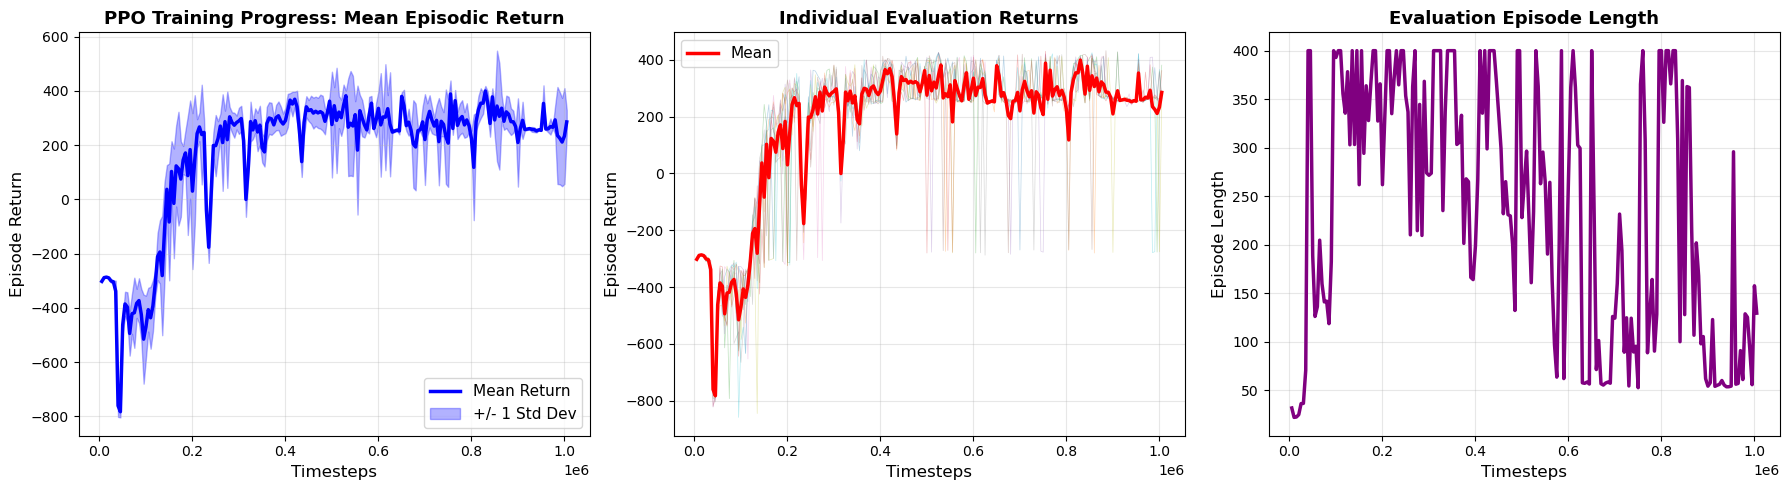


Training Statistics:
Initial mean return: -302.27
Final mean return: 285.30
Best mean return: 399.33 at step 830000
Improvement: 587.57


In [7]:

# Load and plot evaluation results
# Note: Stable-Baselines3 saves evaluations as .npz (NumPy format), not .json
results_file_npz = os.path.join(dirname, 'evaluations.npz')
results_file_json = os.path.join(dirname, 'evaluations.json')

print(f"Looking for results file (npz): {results_file_npz}")
print(f"File exists (npz): {os.path.exists(results_file_npz)}")

if os.path.exists(results_file_npz):
    data = np.load(results_file_npz)
    timesteps = data['timesteps']
    results = data['results']
    ep_lengths = data['ep_lengths'] if 'ep_lengths' in data.files else None

    mean_returns = np.mean(results, axis=1)
    std_returns = np.std(results, axis=1)

    fig, axes = plt.subplots(1, 3 if ep_lengths is not None else 2, figsize=(18, 5))
    ax1, ax2 = axes[0], axes[1]

    ax1.plot(timesteps, mean_returns, linewidth=2.5, label='Mean Return', color='blue')
    ax1.fill_between(
        timesteps,
        mean_returns - std_returns,
        mean_returns + std_returns,
        alpha=0.3,
        color='blue',
        label='+/- 1 Std Dev',
    )
    ax1.set_xlabel('Timesteps', fontsize=12)
    ax1.set_ylabel('Episode Return', fontsize=12)
    ax1.set_title('PPO Training Progress: Mean Episodic Return', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=11)

    for i in range(results.shape[1]):
        ax2.plot(timesteps, results[:, i], alpha=0.3, linewidth=0.5)
    ax2.plot(timesteps, mean_returns, linewidth=2.5, label='Mean', color='red')
    ax2.set_xlabel('Timesteps', fontsize=12)
    ax2.set_ylabel('Episode Return', fontsize=12)
    ax2.set_title('Individual Evaluation Returns', fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=11)

    if ep_lengths is not None:
        mean_lengths = np.mean(ep_lengths, axis=1)
        axes[2].plot(timesteps, mean_lengths, linewidth=2.5, color='purple')
        axes[2].set_xlabel('Timesteps', fontsize=12)
        axes[2].set_ylabel('Episode Length', fontsize=12)
        axes[2].set_title('Evaluation Episode Length', fontsize=13, fontweight='bold')
        axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(dirname, 'learning_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

    best_idx = int(np.argmax(mean_returns))
    print("\nTraining Statistics:")
    print(f"Initial mean return: {mean_returns[0]:.2f}")
    print(f"Final mean return: {mean_returns[-1]:.2f}")
    print(f"Best mean return: {mean_returns[best_idx]:.2f} at step {timesteps[best_idx]}")
    print(f"Improvement: {mean_returns[-1] - mean_returns[0]:.2f}")
elif os.path.exists(results_file_json):
    with open(results_file_json, 'r') as f:
        data = json.load(f)
    timesteps = np.array(data['timesteps'])
    results = np.array(data['results'])
    print("Loaded from JSON format")
else:
    print("Evaluation results file not found!")
    print("Checked locations:")
    print(f"  - {results_file_npz}")
    print(f"  - {results_file_json}")
    print("Run the training cell long enough to reach at least one evaluation checkpoint.")


## Example Rollouts

Run the trained policy on several episodes and visualize the trajectories.


In [ ]:
# Load the best trained model
best_model_path = os.path.join(dirname, 'best_model', 'best_model.zip')
final_model_path = os.path.join(dirname, 'final_model.zip')

if os.path.exists(best_model_path):
    trained_model = PPO.load(best_model_path, device='cpu')
    print(f"Loaded best model: {best_model_path}")
elif os.path.exists(final_model_path):
    trained_model = PPO.load(final_model_path, device='cpu')
    print(f"Loaded final model: {final_model_path}")
elif 'model' in globals():
    trained_model = model
    print("Using in-memory model; no saved model found yet.")
else:
    raise FileNotFoundError("No trained model found. Run the training cell first.")


def rollout_trained_policy(model, env, episodes=20, seed=42):
    trajectories = []
    returns = []
    termination_counts = {}

    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        trajectory = {
            'obs': [obs.copy()],
            'positions': [obs[:2].copy()],
            'actions': [],
            'physical_actions': [],
            'rewards': [],
            'success': False,
            'termination_reason': None,
            'obstacle': env.obstacle_center.copy(),
        }

        total_reward = 0.0
        final_info = {}
        for step in range(env.max_num_steps):
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            trajectory['obs'].append(obs.copy())
            trajectory['positions'].append(obs[:2].copy())
            trajectory['actions'].append(action.copy())
            trajectory['physical_actions'].append(info['physical_action'].copy())
            trajectory['rewards'].append(reward)
            total_reward += reward
            final_info = info

            if terminated or truncated:
                break

        reason = final_info.get('termination_reason', 'unknown')
        trajectory['termination_reason'] = reason
        trajectory['success'] = bool(final_info.get('is_success', False))
        trajectory['total_reward'] = total_reward
        trajectory['positions'] = np.array(trajectory['positions'])
        trajectories.append(trajectory)
        returns.append(total_reward)
        termination_counts[reason] = termination_counts.get(reason, 0) + 1

        print(
            f"Episode {episode + 1:02d}: Return={total_reward:8.2f}, "
            f"Len={step + 1:3d}, Reason={reason}, "
            f"GoalDist={final_info.get('goal_distance', np.nan):.3f}, "
            f"Clearance={final_info.get('clearance', np.nan):.3f}"
        )

    successes = termination_counts.get('success', 0)
    print(f"\nSuccess rate: {successes}/{episodes} ({100 * successes / episodes:.1f}%)")
    print(f"Termination counts: {termination_counts}")
    return trajectories, returns

rollout_env = PlanarQuad()
trajectories, rollout_returns = rollout_trained_policy(trained_model, rollout_env, episodes=20, seed=42)


Visualize trajectories of the rollouts

In [ ]:
num_plots = min(len(trajectories), 5)
fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
if num_plots == 1:
    axes = [axes]

for idx, traj in enumerate(trajectories[:num_plots]):
    ax = axes[idx]
    positions = traj['positions']

    ax.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=2, label='Trajectory', alpha=0.75)
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=9, label='Start', zorder=5)
    ax.plot(x_goal[0], x_goal[1], 'r*', markersize=14, label='Goal', zorder=5)

    obstacle_pos = traj['obstacle']
    obstacle = plt.Circle(obstacle_pos, r, color='orange', alpha=0.55, label='Obstacle')
    inflated = plt.Circle(obstacle_pos, 2 * r, color='orange', alpha=0.15, label='Collision buffer')
    ax.add_patch(inflated)
    ax.add_patch(obstacle)

    ax.add_patch(plt.Circle(positions[0], r, color='green', alpha=0.15))
    ax.add_patch(plt.Circle((x_goal[0], x_goal[1]), r, color='red', alpha=0.15))

    ax.set_xlabel('$p_x$ (m)', fontsize=11)
    ax.set_ylabel('$p_z$ (m)', fontsize=11)
    title = f'Ep {idx + 1}: {traj["termination_reason"]}\nReturn={traj["total_reward"]:.1f}'
    ax.set_title(title, fontsize=11, fontweight='bold', color='green' if traj['success'] else 'black')

    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    if idx == 0:
        ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim([-0.5, 3.5])
    ax.set_ylim([-1.5, 1.5])

plt.tight_layout()
plt.savefig(os.path.join(dirname, 'example_trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRollout returns: {np.round(rollout_returns, 2)}")
print(f"Mean return: {np.mean(rollout_returns):.2f}")
print(f"Std return: {np.std(rollout_returns):.2f}")
